In [4]:
%matplotlib inline
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colormaps

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import umap


In [2]:
pip install umap-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [umap-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
movements_path = "/root/capsule/scratch/all_tongue_movements/all_tongue_movements_04022026.parquet"
all_tongue_movements = pd.read_parquet(movements_path)


/opt/conda/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Mon Apr  6 21:51:59 2026 Construct fuzzy simplicial set
Mon Apr  6 21:51:59 2026 Finding Nearest Neighbors
Mon Apr  6 21:51:59 2026 Building RP forest with 30 trees
Mon Apr  6 21:52:06 2026 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	Stopping threshold met -- exiting after 2 iterations
Mon Apr  6 21:52:56 2026 Finished Nearest Neighbor Search
Mon Apr  6 21:53:01 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Apr  6 21:57:31 2026 Finished embedding


/tmp/ipykernel_77766/1166643227.py:55: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(embedding[:, 0], embedding[:, 1],


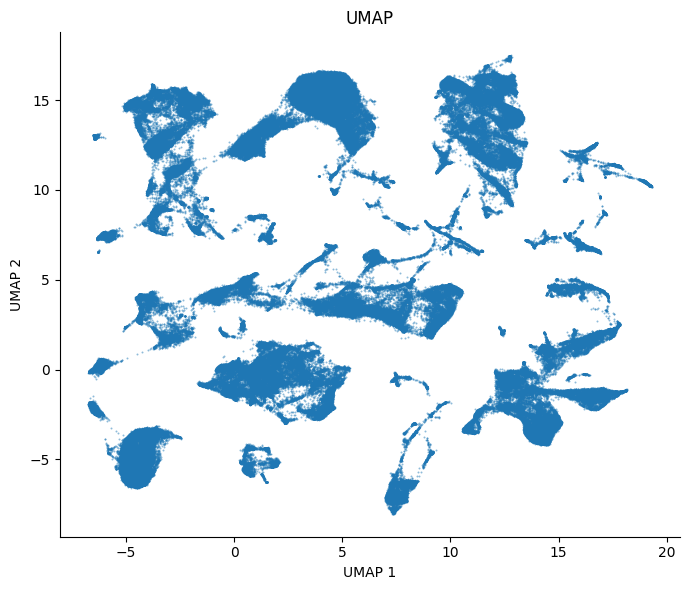

In [6]:


# --- Feature selection ---
# Kinematic features from all_tongue_movements; exclude metadata, ids, and boolean flags
UMAP_FEATURES = [
    'duration', 'min_x', 'max_x', 'min_y', 'max_y',
    'min_xv', 'max_xv', 'min_yv', 'max_yv',
    'peak_velocity', 'mean_velocity', 'total_distance',
    'startpoint_x', 'startpoint_y', 'endpoint_x', 'endpoint_y',
    'time_to_endpoint', 'excursion_angle_deg',
    'max_x_from_jaw', 'max_x_distance', 'max_y_distance',
    'out_duration', 'out_peak_velocity', 'out_mean_velocity', 'out_total_distance',
]

def run_umap_tongue_movements(df, features=UMAP_FEATURES, n_neighbors=30, min_dist=0.1, random_state=42):
    """
    Run UMAP on aggregated tongue movement features.

    Parameters
    ----------
    df : pd.DataFrame
        all_tongue_movements (or filtered subset)
    features : list of str
        Columns to use as input features
    n_neighbors : int
        UMAP n_neighbors parameter
    min_dist : float
        UMAP min_dist parameter
    random_state : int

    Returns
    -------
    embedding : np.ndarray, shape (n, 2)
    df_clean : pd.DataFrame
        Rows of df that were embedded (after dropping all-NaN rows)
    """
    X = df[features].copy()

    # drop rows where all features are NaN
    valid = X.dropna(how='all').index
    X = X.loc[valid]
    df_clean = df.loc[valid].reset_index(drop=True)

    # impute remaining NaNs with column median, then z-score
    X = SimpleImputer(strategy='median').fit_transform(X)
    X = StandardScaler().fit_transform(X)

    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist,
                        random_state=random_state, verbose=True)
    embedding = reducer.fit_transform(X)

    return embedding, df_clean


def plot_umap(embedding, color=None, cmap='viridis', s=2, alpha=0.5, title='UMAP'):
    fig, ax = plt.subplots(figsize=(7, 6))
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1],
                         c=color, cmap=cmap, s=s, alpha=alpha, linewidths=0)
    if color is not None:
        plt.colorbar(scatter, ax=ax)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


# --- Usage ---
embedding, df_embedded = run_umap_tongue_movements(all_tongue_movements)
plot_umap(embedding)

In [24]:
def plot_umap_colored(embedding, df, column, cmap='tab10', s=1, alpha=0.4, figsize=(7, 6)):
    scatter_kw = dict(s=s, alpha=alpha, linewidths=0, rasterized=True)
    labels = df[column].copy().reset_index(drop=True)

    fig, ax = plt.subplots(figsize=figsize)

    # ── continuous ───────────────────────────────────────────────
    if pd.api.types.is_numeric_dtype(labels) and labels.nunique() > 10:
        nan_mask = labels.isna()
        if nan_mask.any():
            ax.scatter(embedding[nan_mask, 0], embedding[nan_mask, 1],
                       c='lightgray', label='NaN', **scatter_kw)

        lo = np.nanpercentile(labels, 5)
        hi = np.nanpercentile(labels, 95)
        clipped = labels.clip(lower=lo, upper=hi)

        sc = ax.scatter(embedding[~nan_mask, 0], embedding[~nan_mask, 1],
                        c=clipped[~nan_mask], cmap=cmap,
                        vmin=lo, vmax=hi, **scatter_kw)
        sc.set_alpha(1.0)
        plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04,
                     label=f'p5–p95 ({lo:.2f}–{hi:.2f})')

        if nan_mask.any():
            leg = ax.legend(fontsize=8)
            for lh in leg.legend_handles:
                lh.set_alpha(1.0)

    # ── categorical ──────────────────────────────────────────────
    else:
        labels = labels.astype(str).replace('nan', 'NaN')
        categories = sorted(labels.unique(), key=lambda x: (x == 'NaN', x))
        n = len(categories)
        cmap_fn = plt.cm.get_cmap(cmap, n)

        for i, cat in enumerate(categories):
            mask = labels == cat
            color = 'lightgray' if cat == 'NaN' else cmap_fn(i / max(n - 1, 1))
            ax.scatter(embedding[mask, 0], embedding[mask, 1],
                       c=[color] * mask.sum(), label=str(cat), **scatter_kw)

        leg = ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1),
                        loc='upper left', borderaxespad=0, markerscale=4)
        for lh in leg.legend_handles:
            lh.set_alpha(1.0)

    ax.set_xlabel('UMAP 1', fontsize=11)
    ax.set_ylabel('UMAP 2', fontsize=11)
    ax.set_title(column, fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

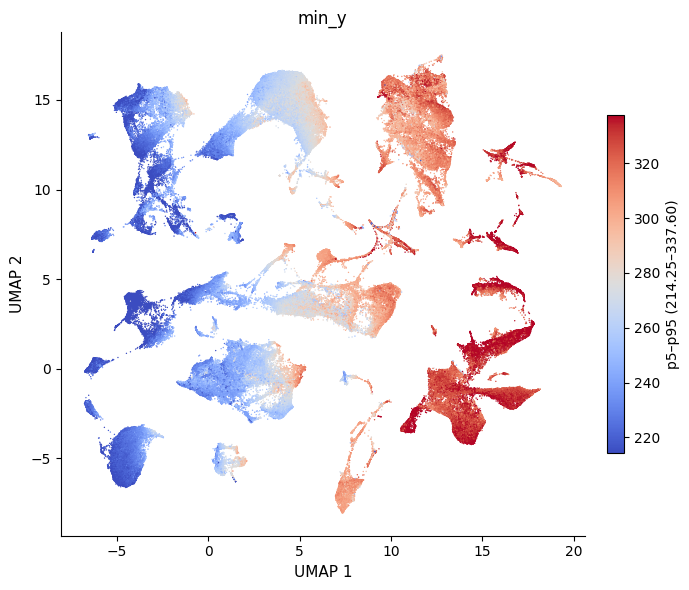

In [32]:
plot_umap_colored(embedding, df_embedded, 'min_y', cmap='coolwarm')

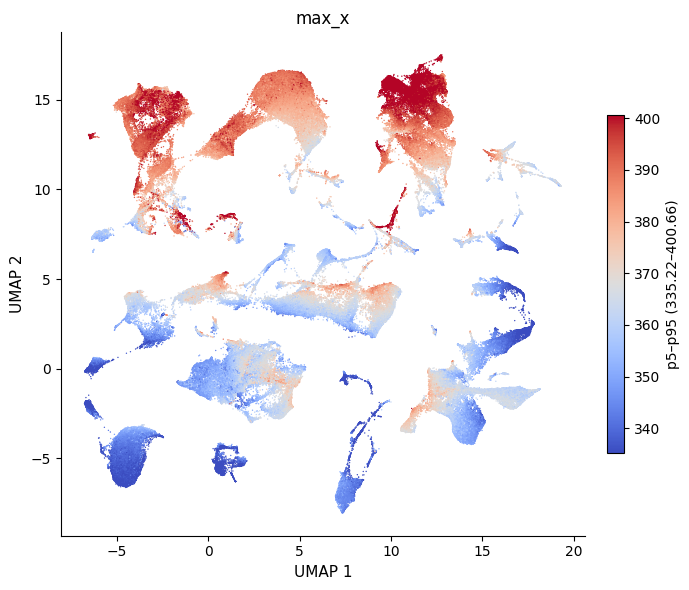

In [33]:
plot_umap_colored(embedding, df_embedded, 'max_x', cmap='coolwarm')

In [12]:
from scipy.stats import spearmanr

def umap_feature_correlations(embedding, df, features=UMAP_FEATURES):
    results = []
    for feat in features:
        col = df[feat].reset_index(drop=True)
        valid = col.notna()
        if valid.sum() < 100:
            continue
        r1, p1 = spearmanr(embedding[valid, 0], col[valid])
        r2, p2 = spearmanr(embedding[valid, 1], col[valid])
        results.append({'feature': feat, 'r_umap1': r1, 'r_umap2': r2,
                        'abs_r_umap1': abs(r1), 'abs_r_umap2': abs(r2)})

    return pd.DataFrame(results).sort_values('abs_r_umap1', ascending=False)

corr_df = umap_feature_correlations(embedding, df_embedded)
print(corr_df.to_string(index=False))

            feature   r_umap1   r_umap2  abs_r_umap1  abs_r_umap2
              min_y  0.942279 -0.011770     0.942279     0.011770
         endpoint_y  0.930967 -0.018504     0.930967     0.018504
excursion_angle_deg  0.896985  0.062659     0.896985     0.062659
       startpoint_y  0.870762 -0.022326     0.870762     0.022326
              max_y  0.844314 -0.019457     0.844314     0.019457
             max_yv -0.465175 -0.054087     0.465175     0.054087
      mean_velocity -0.374699 -0.039202     0.374699     0.039202
     max_y_distance -0.358921 -0.251666     0.358921     0.251666
     total_distance -0.321743 -0.063403     0.321743     0.063403
  out_peak_velocity -0.318141  0.061176     0.318141     0.061176
  out_mean_velocity -0.307004  0.005853     0.307004     0.005853
      peak_velocity -0.244424 -0.021980     0.244424     0.021980
 out_total_distance -0.238900 -0.067778     0.238900     0.067778
             min_yv  0.207884  0.133730     0.207884     0.133730
          

/tmp/ipykernel_77766/2615129165.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_fn = plt.cm.get_cmap(cmap, n)


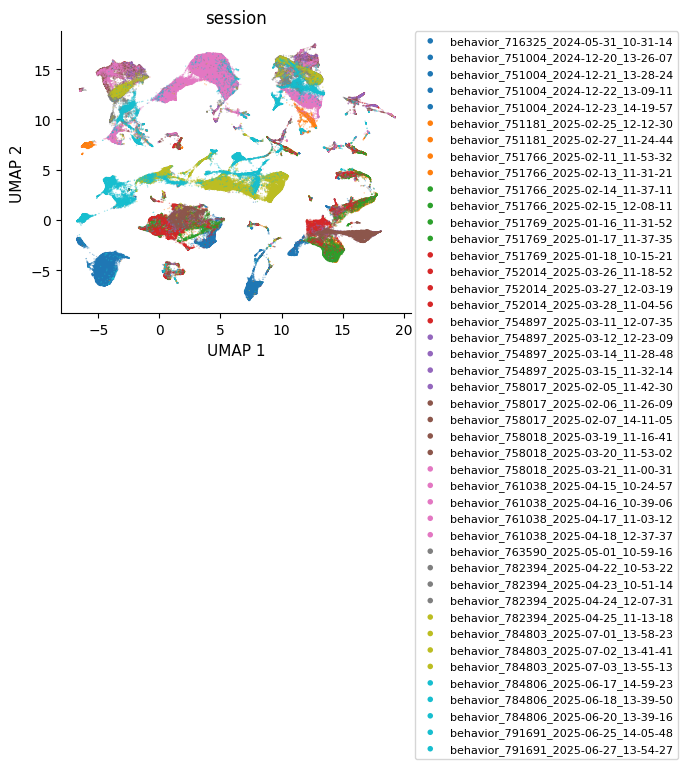

In [35]:
plot_umap_colored(embedding, df_embedded, 'session')

In [38]:
df_embedded

,movement_id,start_time,end_time,duration,min_x,max_x,min_y,max_y,min_xv,max_xv,...,movement_number_in_trial,cue_response_movement_number,movement_before_cue_response,movement_latency_from_go,lick_latency,out_duration,out_peak_velocity,out_mean_velocity,out_total_distance,session
0,1,-46.485600,-46.365600,0.120000,330.882206,369.831238,287.609630,321.827328,-2405.927514,1220.637195,...,<NA>,<NA>,<NA>,<NA>,<NA>,0.089984,1705.237223,793.904635,71.743200,behavior_716325_2024-05-31_10-31-14
1,2,-46.275616,-46.159616,0.116000,319.492875,369.414646,344.512760,387.342063,-2189.170703,2313.255533,...,<NA>,<NA>,<NA>,<NA>,<NA>,0.084000,2780.718613,845.054690,70.279723,behavior_716325_2024-05-31_10-31-14
2,3,-45.673600,-45.569600,0.104000,342.094200,374.136864,346.355380,381.929934,-3361.745177,984.420829,...,<NA>,<NA>,<NA>,<NA>,<NA>,0.077984,1684.429947,619.433255,48.069231,behavior_716325_2024-05-31_10-31-14
3,4,-37.525600,-37.409600,0.116000,326.301474,351.809847,253.160352,296.233811,-1758.746807,1034.347111,...,<NA>,<NA>,<NA>,<NA>,<NA>,0.061984,2287.558495,985.978084,62.230173,behavior_716325_2024-05-31_10-31-14
4,5,-36.087648,-35.991648,0.096000,346.916531,356.723727,322.554984,327.862618,-713.513440,293.460120,...,<NA>,<NA>,<NA>,<NA>,<NA>,0.072000,436.079630,205.007433,14.801037,behavior_716325_2024-05-31_10-31-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246354,9836,4587.998208,4588.120224,0.122016,357.792684,358.853654,313.458744,314.231559,-87.941795,45.886782,...,3322,3,False,2417.694272,6.666144,0.062016,106.970510,48.333916,2.103462,behavior_791691_2025-06-27_13-54-27
246355,9837,4588.184224,4588.186208,0.001984,358.651153,358.764529,312.159120,312.205484,-57.282142,-54.689665,...,3323,3,False,2417.880288,6.666144,0.000000,57.302243,57.302243,NaN,behavior_791691_2025-06-27_13-54-27
246356,9838,4588.254208,4588.266208,0.012000,358.685622,358.982083,311.391830,311.916122,-49.843489,38.286078,...,3324,3,False,2417.950272,6.666144,0.004000,112.014372,61.157532,0.259742,behavior_791691_2025-06-27_13-54-27
246357,9839,4588.290208,4588.520224,0.230016,357.722886,360.208308,311.973410,314.959557,-178.530311,141.827716,...,3325,3,False,2417.986272,6.666144,0.064000,271.792469,107.145039,6.516238,behavior_791691_2025-06-27_13-54-27


In [40]:
session_mask = df_embedded['session'] == 'behavior_716325_2024-05-31_10-31-14'
session_df = df_embedded[session_mask].reset_index(drop=True)

embedding_session, df_session = run_umap_tongue_movements(session_df)

/opt/conda/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Mon Apr  6 22:42:49 2026 Construct fuzzy simplicial set
Mon Apr  6 22:42:49 2026 Finding Nearest Neighbors
Mon Apr  6 22:42:49 2026 Building RP forest with 9 trees
Mon Apr  6 22:42:49 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Mon Apr  6 22:42:50 2026 Finished Nearest Neighbor Search
Mon Apr  6 22:42:50 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon Apr  6 22:43:07 2026 Finished embedding


In [41]:
corr_df = umap_feature_correlations(embedding_session, df_session)
print(corr_df.to_string(index=False))

            feature   r_umap1   r_umap2  abs_r_umap1  abs_r_umap2
excursion_angle_deg -0.935704 -0.621632     0.935704     0.621632
         endpoint_y -0.933842 -0.609125     0.933842     0.609125
              min_y -0.894215 -0.623580     0.894215     0.623580
              max_y -0.792985 -0.423215     0.792985     0.423215
       startpoint_y -0.739846 -0.422252     0.739846     0.422252
         endpoint_x -0.557379 -0.363590     0.557379     0.363590
     max_x_distance -0.543718 -0.342658     0.543718     0.342658
     max_x_from_jaw -0.543659 -0.342550     0.543659     0.342550
              max_x -0.543659 -0.342550     0.543659     0.342550
             max_yv  0.490856  0.660820     0.490856     0.660820
     total_distance  0.403985  0.692127     0.403985     0.692127
              min_x -0.356009 -0.656403     0.356009     0.656403
     max_y_distance  0.354053  0.488563     0.354053     0.488563
      mean_velocity  0.331358  0.533450     0.331358     0.533450
 out_total

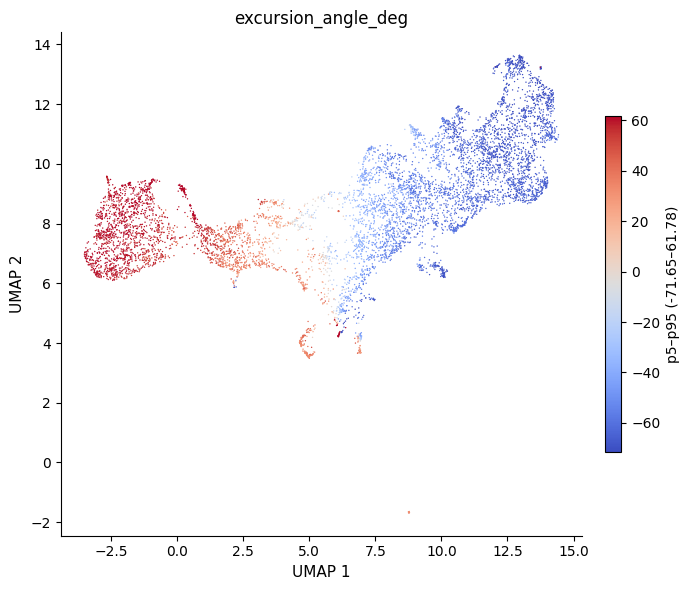

In [42]:
plot_umap_colored(embedding_session, df_session, 'excursion_angle_deg', cmap='coolwarm')

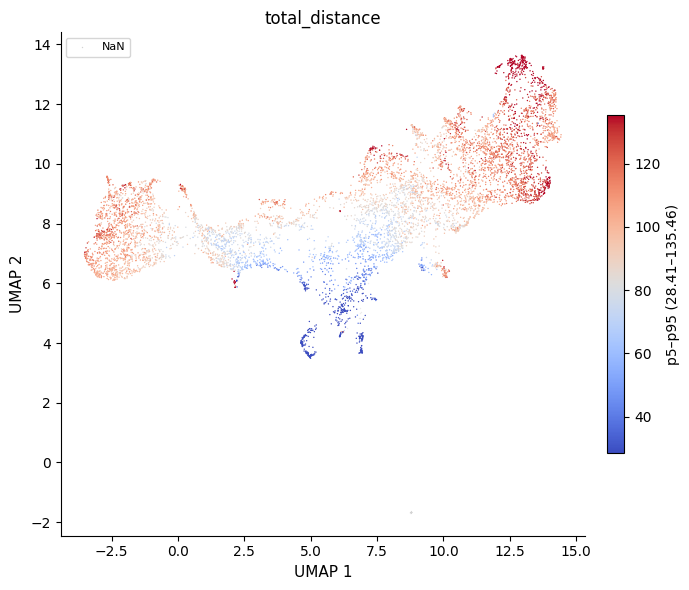

In [43]:
plot_umap_colored(embedding_session, df_session, 'total_distance', cmap='coolwarm')

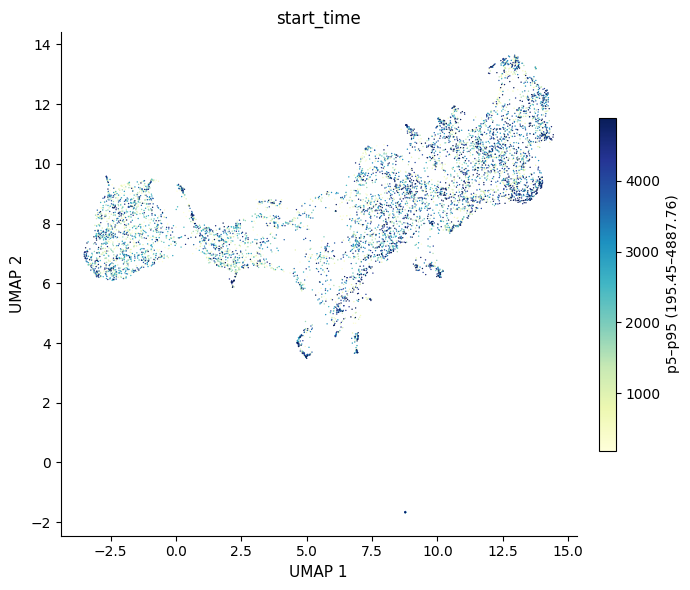

In [51]:
plot_umap_colored(embedding_session, df_session, 'start_time', cmap='YlGnBu',alpha=1)

Running UMAP on raw features...


/opt/conda/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Mon Apr  6 22:59:40 2026 Construct fuzzy simplicial set
Mon Apr  6 22:59:40 2026 Finding Nearest Neighbors
Mon Apr  6 22:59:40 2026 Building RP forest with 30 trees
Mon Apr  6 22:59:44 2026 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	Stopping threshold met -- exiting after 2 iterations
Mon Apr  6 23:00:23 2026 Finished Nearest Neighbor Search
Mon Apr  6 23:00:25 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Apr  6 23:05:01 2026 Finished embedding
Running UMAP on session-demeaned features...


/opt/conda/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Mon Apr  6 23:05:03 2026 Construct fuzzy simplicial set
Mon Apr  6 23:05:03 2026 Finding Nearest Neighbors
Mon Apr  6 23:05:03 2026 Building RP forest with 30 trees
Mon Apr  6 23:05:06 2026 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	Stopping threshold met -- exiting after 2 iterations
Mon Apr  6 23:05:45 2026 Finished Nearest Neighbor Search
Mon Apr  6 23:05:48 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Apr  6 23:10:19 2026 Finished embedding


/tmp/ipykernel_77766/42020156.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n_sess)
/tmp/ipykernel_77766/42020156.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n_sess)


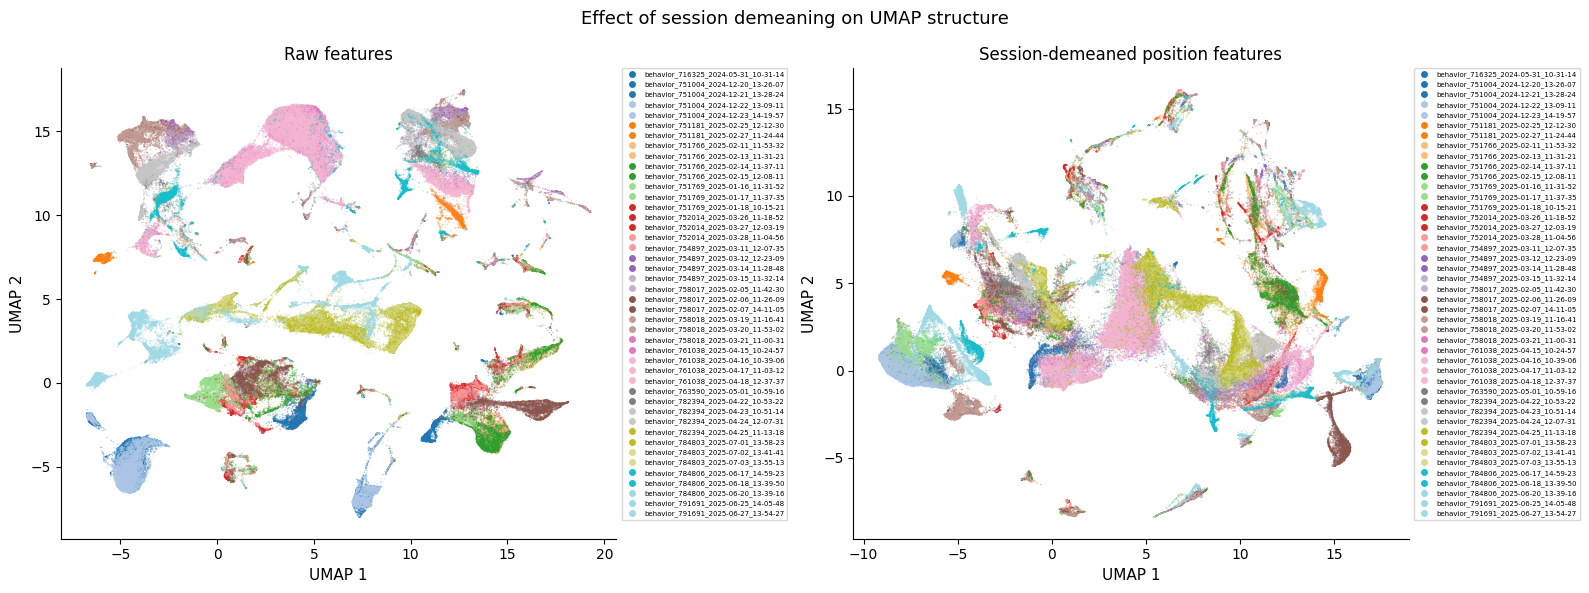

In [52]:
def compare_umap_normalization(df, features=UMAP_FEATURES, 
                                position_features=None,
                                n_neighbors=30, min_dist=0.1, random_state=42):
    """
    Run UMAP on raw vs session-demeaned features and plot side by side colored by session.

    Parameters
    ----------
    df : pd.DataFrame
        all_tongue_movements or filtered subset.
    features : list of str
        Full feature set for UMAP.
    position_features : list of str
        Subset of features to demean within session. If None, uses default position features.
    """
    if position_features is None:
        position_features = [
            'startpoint_x', 'startpoint_y', 'endpoint_x', 'endpoint_y',
            'min_x', 'max_x', 'min_y', 'max_y',
            'max_x_from_jaw', 'max_y_from_jaw', 'excursion_angle_deg',
        ]
    position_features = [f for f in position_features if f in df.columns]

    # ── raw ──────────────────────────────────────────────────────
    print("Running UMAP on raw features...")
    embedding_raw, df_raw = run_umap_tongue_movements(
        df, features=features, n_neighbors=n_neighbors,
        min_dist=min_dist, random_state=random_state
    )

    # ── session-demeaned ─────────────────────────────────────────
    print("Running UMAP on session-demeaned features...")
    df_demeaned = df.copy()
    for feat in position_features:
        df_demeaned[feat] = df_demeaned.groupby('session')[feat].transform(
            lambda x: x - x.mean()
        )
    embedding_norm, df_norm = run_umap_tongue_movements(
        df_demeaned, features=features, n_neighbors=n_neighbors,
        min_dist=min_dist, random_state=random_state
    )

    # ── plot side by side ────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    scatter_kw = dict(s=1, alpha=0.4, linewidths=0, rasterized=True)

    for ax, embedding, df_plot, title in zip(
        axes,
        [embedding_raw, embedding_norm],
        [df_raw, df_norm],
        ['Raw features', 'Session-demeaned position features']
    ):
        sessions = df_plot['session'].astype('category')
        codes = sessions.cat.codes
        n_sess = len(sessions.cat.categories)
        cmap = plt.cm.get_cmap('tab20', n_sess)

        ax.scatter(embedding[:, 0], embedding[:, 1], c=codes,
                   cmap='tab20', vmin=0, vmax=n_sess, **scatter_kw)

        handles = [
            plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=cmap(i / max(n_sess - 1, 1)),
                       markersize=6, label=sess)
            for i, sess in enumerate(sessions.cat.categories)
        ]
        leg = ax.legend(handles=handles, fontsize=5, bbox_to_anchor=(1.01, 1),
                        loc='upper left', borderaxespad=0)
        for lh in leg.legend_handles:
            lh.set_alpha(1.0)

        ax.set_title(title, fontsize=12)
        ax.set_xlabel('UMAP 1', fontsize=11)
        ax.set_ylabel('UMAP 2', fontsize=11)
        ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle('Effect of session demeaning on UMAP structure', fontsize=13)
    plt.tight_layout()
    plt.show()

    return embedding_raw, df_raw, embedding_norm, df_norm


# --- Usage ---
embedding_raw, df_raw, embedding_norm, df_norm = compare_umap_normalization(
    all_tongue_movements
)

In [53]:
corr_df = umap_feature_correlations(embedding_raw, df_raw)
print(corr_df.to_string(index=False))

            feature   r_umap1   r_umap2  abs_r_umap1  abs_r_umap2
              min_y  0.942279 -0.011770     0.942279     0.011770
         endpoint_y  0.930967 -0.018504     0.930967     0.018504
excursion_angle_deg  0.896985  0.062659     0.896985     0.062659
       startpoint_y  0.870762 -0.022326     0.870762     0.022326
              max_y  0.844314 -0.019457     0.844314     0.019457
             max_yv -0.465175 -0.054087     0.465175     0.054087
      mean_velocity -0.374699 -0.039202     0.374699     0.039202
     max_y_distance -0.358921 -0.251666     0.358921     0.251666
     total_distance -0.321743 -0.063403     0.321743     0.063403
  out_peak_velocity -0.318141  0.061176     0.318141     0.061176
  out_mean_velocity -0.307004  0.005853     0.307004     0.005853
      peak_velocity -0.244424 -0.021980     0.244424     0.021980
 out_total_distance -0.238900 -0.067778     0.238900     0.067778
             min_yv  0.207884  0.133730     0.207884     0.133730
          

In [54]:
corr_df = umap_feature_correlations(embedding_norm, df_norm)
print(corr_df.to_string(index=False))

            feature   r_umap1   r_umap2  abs_r_umap1  abs_r_umap2
         endpoint_y  0.871309 -0.224661     0.871309     0.224661
excursion_angle_deg  0.862342 -0.208577     0.862342     0.208577
              min_y  0.858469 -0.127324     0.858469     0.127324
       startpoint_y  0.814921 -0.224095     0.814921     0.224095
              max_y  0.812084 -0.333580     0.812084     0.333580
             max_yv -0.411467 -0.402976     0.411467     0.402976
     max_y_distance -0.326266 -0.330619     0.326266     0.330619
      mean_velocity -0.318139 -0.228692     0.318139     0.228692
     total_distance -0.297630 -0.518085     0.297630     0.518085
  out_peak_velocity -0.276249 -0.392942     0.276249     0.392942
  out_mean_velocity -0.274270 -0.115747     0.274270     0.115747
 out_total_distance -0.228094 -0.490619     0.228094     0.490619
       startpoint_x  0.212795 -0.007230     0.212795     0.007230
      peak_velocity -0.182872 -0.509886     0.182872     0.509886
          

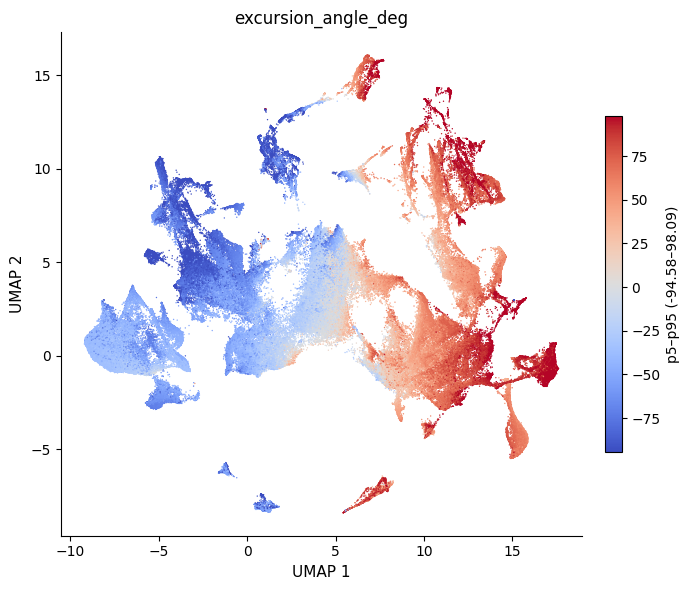

In [55]:
plot_umap_colored(embedding_norm, df_norm, 'excursion_angle_deg', cmap='coolwarm')

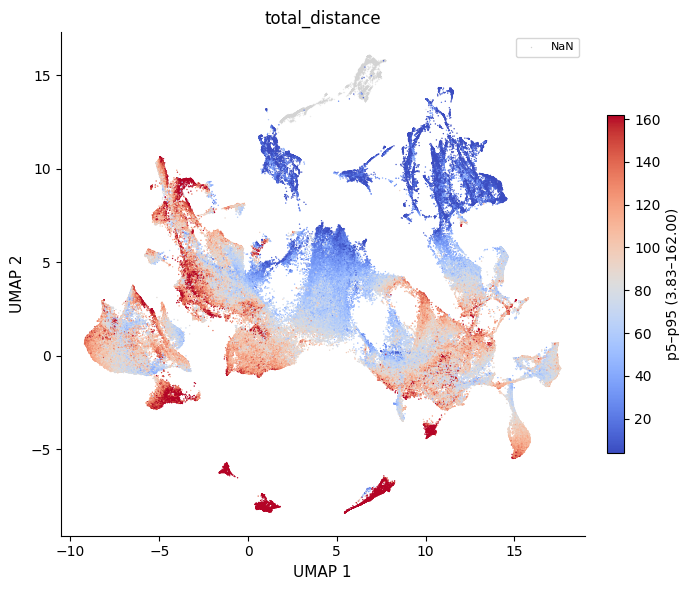

In [60]:
plot_umap_colored(embedding_norm, df_norm, 'total_distance', cmap='coolwarm')

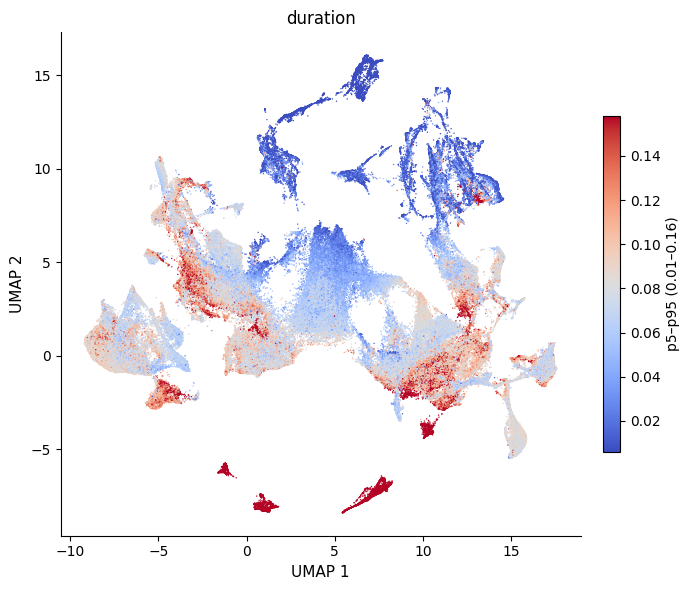

In [62]:
plot_umap_colored(embedding_norm, df_norm, 'duration', cmap='coolwarm')

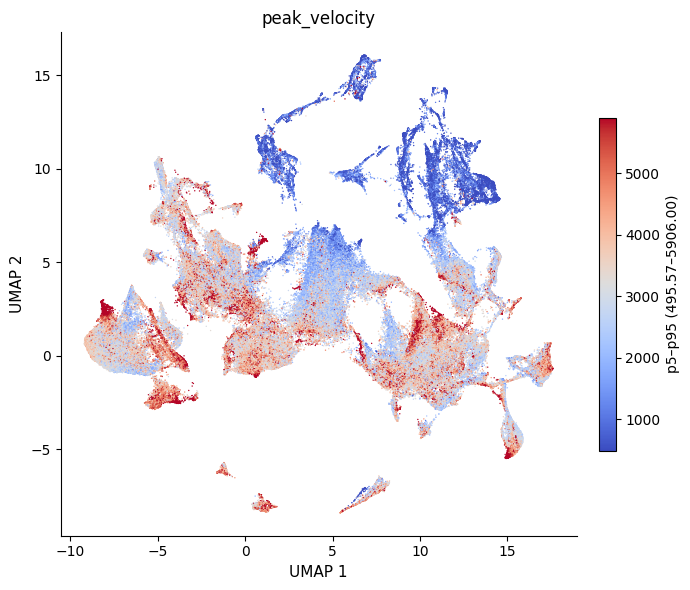

In [ ]:
plot_umap_colored(embedding_norm, df_norm, 'peak_velocity', cmap='coolwarm')

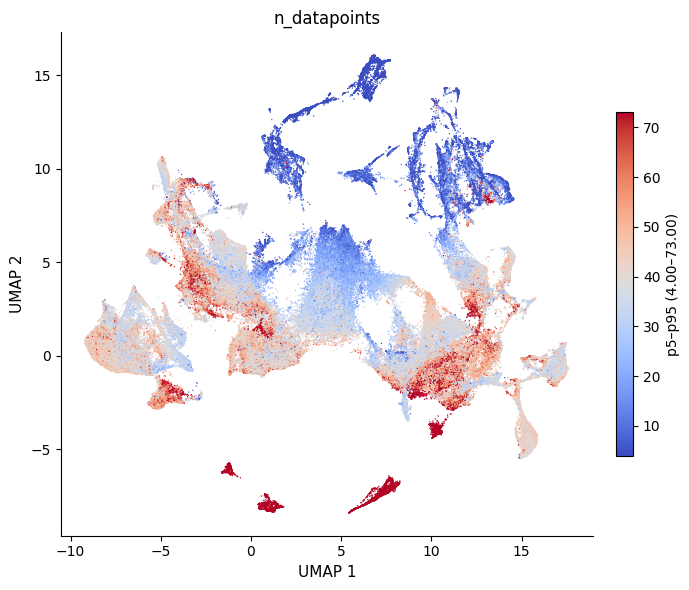

In [65]:
plot_umap_colored(embedding_norm, df_norm, 'n_datapoints', cmap='coolwarm')

In [61]:
import numpy as np
from pathlib import Path

UMAP_SAVE_DIR = Path('/root/capsule/scratch/umap')
UMAP_SAVE_DIR.mkdir(exist_ok=True)

# ── single session ───────────────────────────────────────────────
np.save(UMAP_SAVE_DIR / 'embedding_single_session.npy', embedding_session)
df_session.to_parquet(UMAP_SAVE_DIR / 'df_single_session.parquet')

# ── full dataset, raw ────────────────────────────────────────────
np.save(UMAP_SAVE_DIR / 'embedding_raw.npy', embedding_raw)
df_raw.to_parquet(UMAP_SAVE_DIR / 'df_raw.parquet')

# ── full dataset, session-demeaned ───────────────────────────────
np.save(UMAP_SAVE_DIR / 'embedding_norm.npy', embedding_norm)
df_norm.to_parquet(UMAP_SAVE_DIR / 'df_norm.parquet')

print("Saved:")
for f in sorted(UMAP_SAVE_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)")

Saved:
  df_norm.parquet  (66.9 MB)
  df_raw.parquet  (66.9 MB)
  df_single_session.parquet  (2.2 MB)
  embedding_norm.npy  (2.0 MB)
  embedding_raw.npy  (2.0 MB)
  embedding_single_session.npy  (0.1 MB)
